In [1]:
import pandas as pd
import os
import ast
import seaborn as sns
import matplotlib.pyplot as plt
import json

### Informations : 

Pour chaque athlète, on a toutes ses activités. Pour chaque activité, si on a accès aux splits on les utilise car plus précis. On va donc utiliser les données communes aux activités et aux splits pour l'analyse.
Données utilisées :
1. Dans df_final : 

- sport_type (Run, Ride, Swim, Workout...)
- start_date
- athlete_id
- activity_id
- distance
- moving_time
- average_heartrate
- average_speed_km_h
- average_speed_min_km

2. Dans df_athletes_stats : (je rajoute les infos des athletes dont j'ai pas l'authorisation à la main)

- athlete_id (ou Nom Prénom à voir)
- Total_distance_run
- Total_distance_ride
- Total_distance_swim
- FC Max (?)
- 5km PB
- 10km PB
- 21km PB
- 42km PB
- Nb_activities_run
- Nb_activities_ride
- Nb_activities_swim
- Nb_activities

In [2]:
folder = "Data"
df = pd.concat([pd.read_csv(os.path.join(folder, f)) for f in os.listdir(folder) if f.endswith(".csv")], ignore_index=True) # Concat toutes les data dans un seul df
pd.set_option("display.max_colwidth", None)

In [3]:
# Suppression des colonnes inutiles
cols_to_drop = [
    'photo_count', 'from_accepted_tag', 'achievement_count', 'location_state', 'kudos_count', 'comment_count', 'map',
    'trainer', 'commute', 'flagged', 'start_latlng', 'end_latlng', 'upload_id', 'upload_id_str', 'external_id',
    'pr_count', 'total_photo_count', 'has_kudoed', 'location_country', 'location_city', 'start_date_local',
    'display_hide_heartrate_option', 'elapsed_time', 'utc_offset', 'device_watts', 'workout_type', 'type',
    'resource_state', 'timezone', 'elev_low', 'elev_high', 'manual', 'kilojoules', 'perceived_exertion',
    'prefer_perceived_exertion', 'segment_efforts', 'description', 'stats_visibility', 'hide_from_home', 'photos',
    'similar_activities', 'device_name', 'message', 'gear', 'gear_id', 'embed_token', 'errors', 'splits_standard',
    'has_heartrate', 'available_zones', 'private', 'visibility', 'heartrate_opt_out', 'calories', 'average_temp',
    'name', 'athlete_count', 'average_cadence', 'best_efforts'
]
df = df.drop(columns=cols_to_drop, errors='ignore')

# Nettoyage colonne 'athlete'
df['athlete'] = df['athlete'].apply(ast.literal_eval)
df['athlete_id'] = df['athlete'].apply(lambda x: x['id'] if isinstance(x, dict) else None)
df = df.drop(columns=['athlete'])

# Renommage des colonnes
df = df.rename(columns={'id': 'activity_id'})

# Calculs sur les vitesses
df['moving_time'] = df['moving_time'] / 60  # minutes
df['average_speed_km_h'] = df['average_speed'] * 3.6
df['average_speed_min_km'] = 60 / df['average_speed_km_h']
df['max_speed_km_h_activity'] = df['max_speed'] * 3.6
df['max_speed_min_km_activity'] = 60 / df['max_speed_km_h_activity']
df = df.drop(columns=["average_speed", 'max_speed'])

# Conversion date
df['start_date'] = pd.to_datetime(df['start_date'])

# Renommage pour éviter conflits dans les splits
df = df.rename(columns={
    'distance': 'distance_activity',
    'moving_time': 'moving_time_activity',
    'average_speed_km_h': 'average_speed_km_h_activity',
    'average_speed_min_km': 'average_speed_min_km_activity',
    'average_heartrate': 'average_heartrate_activity',
    'total_elevation_gain': 'elevation_gain_activity',
    'max_heartrate': 'max_heartrate_activity',
    'average_watts': 'average_watts_activity',
    'max_watts': 'max_watts_activity',
    'weighted_average_watts': 'weighted_average_watts_activity'
})

# Tri par athlète et date
df = df.sort_values(by=['athlete_id', 'start_date'])

# Distances cumulées par sport
def cumulative_distance(df, sport):
    return (
        df.groupby('athlete_id', group_keys=False)
        .apply(lambda x: x.loc[x['sport_type'] == sport, 'distance_activity'].cumsum())
    )

df['cumulative_distance_run'] = cumulative_distance(df, 'Run')
df['cumulative_distance_ride'] = cumulative_distance(df, 'Ride')
df['cumulative_distance_swim'] = cumulative_distance(df, 'Swim')

# Traitement de splits_metric
df['splits_metric'] = df['splits_metric'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_splits_metric = df.explode("splits_metric").reset_index(drop=True)
df_splits_metric = pd.concat([df_splits_metric.drop(columns=["splits_metric"]), df_splits_metric["splits_metric"].apply(pd.Series)], axis=1)
df = df.drop(columns=["splits_metric"])

# Traitement des laps
df['laps'] = df['laps'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_laps = df.explode("laps").reset_index(drop=True)
df_laps = pd.concat([df_laps.drop(columns=["laps"]), df_laps["laps"].apply(pd.Series)], axis=1)
df = df.drop(columns=["laps"])

# Traitement de df_splits_metric
df_splits_metric['start_date'] = pd.to_datetime(df_splits_metric['start_date'])
df_splits_metric['average_speed_km_h'] = df_splits_metric['average_speed'] * 3.6
df_splits_metric['average_speed_min_km'] = 60 / df_splits_metric['average_speed_km_h']
df_splits_metric = df_splits_metric.rename(columns={
    'distance': 'distance_split',
    'moving_time': 'moving_time_split',
    'average_speed': 'average_speed_split',
    'average_speed_km_h': 'average_speed_km_h_split',
    'average_speed_min_km': 'average_speed_min_km_split',
    'average_heartrate': 'average_heartrate_split'
})
df_splits_metric = df_splits_metric.drop(columns=[
    'elapsed_time', 'elevation_difference', 0, 'average_grade_adjusted_speed',
    'cumulative_distance_swim', 'cumulative_distance_ride', 'cumulative_distance_run',
    'pace_zone', 'split'
], errors='ignore')

# Supprimer aussi les colonnes 'laps' ou 'splits_metric' restantes dans les autres DataFrames (plus pratique)
for col in ['splits_metric', 'laps']:
    for d in [df, df_splits_metric, df_laps]:
        if col in d.columns:
            d.drop(columns=[col], inplace=True)

# Colonnes utiles pour l'analyse des laps
cols_to_keep_laps = [
    'activity_id', 'athlete_id', 'start_date', 'sport_type',
    'lap_index', 'split', 'distance', 'moving_time', 'elapsed_time',
    'average_speed', 'max_speed', 'average_heartrate', 'max_heartrate',
    'average_watts'
]

# Garder uniquement ces colonnes (vérifie que toutes sont présentes)
df_laps_clean = df_laps[[col for col in cols_to_keep_laps if col in df_laps.columns]].copy()

df_laps_clean.rename(columns={
    'distance': 'distance_lap',
    'moving_time': 'moving_time_lap',
    'elapsed_time': 'elapsed_time_lap',
    'average_speed': 'average_speed_lap',
    'max_speed': 'max_speed_lap',
    'average_heartrate': 'average_heartrate_lap',
    'max_heartrate': 'max_heartrate_lap',
    'average_watts': 'average_watts_lap'
}, inplace=True)

df_laps_clean['average_speed_km_h_lap'] = df_laps_clean['average_speed_lap'] * 3.6
df_laps_clean['average_speed_min_km_lap'] = 60 / df_laps_clean['average_speed_km_h_lap']

C:\Users\Mathi\AppData\Local\Temp\ipykernel_16556\3094598203.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x['sport_type'] == sport, 'distance_activity'].cumsum())
C:\Users\Mathi\AppData\Local\Temp\ipykernel_16556\3094598203.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x['sport_type'] == sport, 'distance_activity'].cumsum())
C:\Users\Mathi\AppData

In [4]:
print(df.columns)
print(len(df))

Index(['distance_activity', 'moving_time_activity', 'elevation_gain_activity',
       'sport_type', 'activity_id', 'start_date', 'average_watts_activity',
       'average_heartrate_activity', 'max_heartrate_activity', 'athlete_id',
       'max_watts_activity', 'weighted_average_watts_activity',
       'average_speed_km_h_activity', 'average_speed_min_km_activity',
       'max_speed_km_h_activity', 'max_speed_min_km_activity',
       'cumulative_distance_run', 'cumulative_distance_ride',
       'cumulative_distance_swim'],
      dtype='object')
946


In [5]:
df.tail(2)

,distance_activity,moving_time_activity,elevation_gain_activity,sport_type,activity_id,start_date,average_watts_activity,average_heartrate_activity,max_heartrate_activity,athlete_id,max_watts_activity,weighted_average_watts_activity,average_speed_km_h_activity,average_speed_min_km_activity,max_speed_km_h_activity,max_speed_min_km_activity,cumulative_distance_run,cumulative_distance_ride,cumulative_distance_swim
452,2240.8,12.700000,17.0,Run,14161505025,2025-04-13 05:54:16+00:00,298.9,129.0,143.0,118945026,485.0,270.0,10.5876,5.667007,15.768,3.805175,3137180.9,NaN,NaN
451,42496.3,192.616667,207.0,Run,14163073729,2025-04-13 06:30:10+00:00,356.3,168.5,186.0,118945026,558.0,363.0,13.2372,4.532681,19.152,3.132832,3179677.2,NaN,NaN


In [6]:
df_laps_clean.columns

Index(['activity_id', 'athlete_id', 'start_date', 'start_date', 'sport_type',
       'lap_index', 'split', 'distance_lap', 'moving_time_lap',
       'elapsed_time_lap', 'average_speed_lap', 'max_speed_lap',
       'average_heartrate_lap', 'max_heartrate_lap', 'average_watts_lap',
       'average_speed_km_h_lap', 'average_speed_min_km_lap'],
      dtype='object')

In [7]:
df_laps_clean.head(2)

,activity_id,athlete_id,start_date,start_date,sport_type,lap_index,split,distance_lap,moving_time_lap,elapsed_time_lap,average_speed_lap,max_speed_lap,average_heartrate_lap,max_heartrate_lap,average_watts_lap,average_speed_km_h_lap,average_speed_min_km_lap
0,8301530515,111468957,2022-12-28 09:40:18+00:00,2022-12-28T09:40:18Z,Run,1.0,1.0,1000.0,347.0,347.0,2.88,4.237,NaN,NaN,NaN,10.368,5.787037
1,8301530515,111468957,2022-12-28 09:40:18+00:00,2022-12-28T09:46:07Z,Run,2.0,2.0,1000.0,296.0,296.0,3.38,4.294,NaN,NaN,NaN,12.168,4.930966


In [8]:
df_splits_metric.columns

Index(['distance_activity', 'moving_time_activity', 'elevation_gain_activity',
       'sport_type', 'activity_id', 'start_date', 'average_watts_activity',
       'average_heartrate_activity', 'max_heartrate_activity', 'athlete_id',
       'max_watts_activity', 'weighted_average_watts_activity',
       'average_speed_km_h_activity', 'average_speed_min_km_activity',
       'max_speed_km_h_activity', 'max_speed_min_km_activity',
       'distance_split', 'moving_time_split', 'average_speed_split',
       'average_heartrate_split', 'average_speed_km_h_split',
       'average_speed_min_km_split'],
      dtype='object')

In [9]:
df_splits_metric.tail(2)

,distance_activity,moving_time_activity,elevation_gain_activity,sport_type,activity_id,start_date,average_watts_activity,average_heartrate_activity,max_heartrate_activity,athlete_id,...,average_speed_km_h_activity,average_speed_min_km_activity,max_speed_km_h_activity,max_speed_min_km_activity,distance_split,moving_time_split,average_speed_split,average_heartrate_split,average_speed_km_h_split,average_speed_min_km_split
8260,42496.3,192.616667,207.0,Run,14163073729,2025-04-13 06:30:10+00:00,356.3,168.5,186.0,118945026,...,13.2372,4.532681,19.152,3.132832,999.4,302.0,3.31,159.301325,11.916,5.035247
8261,42496.3,192.616667,207.0,Run,14163073729,2025-04-13 06:30:10+00:00,356.3,168.5,186.0,118945026,...,13.2372,4.532681,19.152,3.132832,495.1,119.0,4.16,169.907563,14.976,4.006410


In [10]:
# Étape 1 : activités qui n'ont pas de splits
df_activity_no_splits = df_splits_metric[df_splits_metric['distance_split'].isnull()].copy()

# Étape 2 : activités qui ont des splits
df_activity_only_splits = df_splits_metric[df_splits_metric['distance_split'].notnull()].copy()
df_activity_only_splits.columns

# Étape 3 : On enlève toutes les colonnes liées aux splits dans df_activity_no_splits et pareil pour les colonnes liées aux acitvités dans df_activity_only_splits
df_activity_only_splits = df_activity_only_splits.drop(columns=[col for col in df_activity_only_splits.columns if 'activity' in col and col != 'activity_id'], errors='ignore') # On garde 'activity_id' pour la fusion
df_activity_no_splits = df_activity_no_splits.drop(columns=[col for col in df_activity_no_splits.columns if 'split' in col], errors='ignore')

# Étape 4 : On renomme les colonnes pour avoir les mêmes dans les deux dataframes
df_activity_only_splits = df_activity_only_splits.rename(columns={
    'distance_split': 'distance',
    'moving_time_split': 'moving_time',
    'average_speed_km_h_split': 'average_speed_km_h',
    'average_speed_min_km_split': 'average_speed_min_km',
    'average_heartrate_split': 'average_heartrate'
})
df_activity_only_splits = df_activity_only_splits.drop(columns=['average_speed_split'])

df_activity_no_splits = df_activity_no_splits.rename(columns={
    'distance_activity': 'distance',
    'moving_time_activity': 'moving_time',
    'average_speed_km_h_activity': 'average_speed_km_h',
    'average_speed_min_km_activity': 'average_speed_min_km',
    'average_heartrate_activity': 'average_heartrate'
})
df_activity_no_splits = df_activity_no_splits.drop(columns=[col for col in df_activity_no_splits.columns if col not in df_activity_only_splits.columns], errors='ignore') # On garde 'activity_id' pour la fusion

# Étape 5 : On fusionne les deux dataFrames pour avoir notre df final
df_final = pd.concat([df_activity_no_splits, df_activity_only_splits], ignore_index=True)
df_final.shape

(8262, 9)

In [11]:
df_final.head()

,distance,moving_time,sport_type,activity_id,start_date,average_heartrate,athlete_id,average_speed_km_h,average_speed_min_km
0,10054.6,42.383333,Run,10240766861,2023-11-18 14:59:44+00:00,183.0,111468957,14.2344,4.215141
1,9198.8,49.066667,Run,10251439334,2023-11-20 13:53:09+00:00,156.7,111468957,11.2500,5.333333
2,9628.9,52.400000,Run,10274927243,2023-11-24 17:19:06+00:00,163.0,111468957,11.0268,5.441288
3,12136.2,66.316667,Run,10286045530,2023-11-26 14:55:01+00:00,160.0,111468957,10.9800,5.464481
4,10029.6,52.333333,Run,10296761055,2023-11-28 17:15:03+00:00,163.7,111468957,11.4984,5.218117


In [12]:
# On crée un dataFrame pour stocker les stats des athlètes
df_athletes_stats = pd.DataFrame(columns=['athlete_id', 'Total_distance_run', 'Total_distance_ride', 'Total_distance_swim', 'FC Max', '5km PB', '5km PB pace', '10km PB', '10km PB pace', '21km PB',
                                          '21km PB pace', '42km PB', '42km PB pace', 'Nb_activities', 'Nb_activities_run', 'Nb_activities_ride', 'Nb_activities_swim'])
df_athletes_stats['Nb_activities_run'] = df_final[df_final['sport_type']=='Run'].groupby('athlete_id')['activity_id'].nunique() # On compte le nombre d'activités par athlète pour chaque sport
df_athletes_stats['Nb_activities_ride'] = df_final[df_final['sport_type']=='Ride'].groupby('athlete_id')['activity_id'].nunique()
df_athletes_stats['Nb_activities_swim'] = df_final[df_final['sport_type']=='Swim'].groupby('athlete_id')['activity_id'].nunique()
df_athletes_stats['athlete_id'] = df_final['athlete_id'].unique() # On ajoute les IDs des athlètes

# On regarde les distances totales aprcourues par chaque athlète pour chaque sport
total_distance_run = df_final[df_final['sport_type']=='Run'].groupby('athlete_id')['distance'].sum()
total_distance_ride = df_final[df_final['sport_type']=='Ride'].groupby('athlete_id')['distance'].sum()
total_distance_swim = df_final[df_final['sport_type']=='Swim'].groupby('athlete_id')['distance'].sum()
df_athletes_stats['Total_distance_run'] = df_athletes_stats['athlete_id'].map(total_distance_run)
df_athletes_stats['Total_distance_ride'] = df_athletes_stats['athlete_id'].map(total_distance_ride)
df_athletes_stats['Total_distance_swim'] = df_athletes_stats['athlete_id'].map(total_distance_swim)

# On regarde la FC max de chaque athlète (onf fait la moyenne sur les 10 plus hautes FC max, sans compter celles >210 bpm)
fc_valides = df[df["max_heartrate_activity"] < 210].groupby('athlete_id')["max_heartrate_activity"].apply(lambda x: x.nlargest(10).mean())
df_athletes_stats['FC Max'] = df_athletes_stats['athlete_id'].map(fc_valides)

# On regarde les records de chaque athlète sur 5km, 10km, 21km et 42km
best_5km = df[(df['sport_type'] == 'Run') & (df['distance_activity'] >= 4.8*1000)].groupby('athlete_id')['moving_time_activity'].min().round(2) # Encadrer 'distance' entre 4.8 et 5.2 par ex ?
df_athletes_stats['5km PB'] = df_athletes_stats['athlete_id'].map(best_5km)
best_10km = df[(df['sport_type'] == 'Run') & (df['distance_activity'] >= 9.8*1000)].groupby('athlete_id')['moving_time_activity'].min().round(2)
df_athletes_stats['10km PB'] = df_athletes_stats['athlete_id'].map(best_10km)
best_21km = df[(df['sport_type'] == 'Run') & (df['distance_activity'] >= 20*1000)].groupby('athlete_id')['moving_time_activity'].min().round(2)
df_athletes_stats['21km PB'] = df_athletes_stats['athlete_id'].map(best_21km)
best_42km = df[(df['sport_type'] == 'Run') & (df['distance_activity'] >= 41.5*1000)].groupby('athlete_id')['moving_time_activity'].min().round(2)
df_athletes_stats['42km PB'] = df_athletes_stats['athlete_id'].map(best_42km)

In [13]:
# Charger les stats ajoutées manuellement
manual_stats = pd.read_csv("manual_stats.csv")

# Réorganiser les colonnes selon les colonnes présentes au moment du chargement
common_columns = [col for col in df_athletes_stats.columns if col in manual_stats.columns]
manual_stats = manual_stats[common_columns]

# Concaténer les deux DataFrames (pandas remplira les colonnes manquantes avec NaN)
df_athletes_stats = pd.concat([df_athletes_stats, manual_stats], ignore_index=True)

df_athletes_stats = df_athletes_stats.drop_duplicates(subset='athlete_id', keep='last') # On enlève les doublons (au cas où)

# Puis preprocessing de tout de dataframe

df_athletes_stats['Nb_activities'] = df_athletes_stats['Nb_activities_run'] + df_athletes_stats['Nb_activities_ride'] + df_athletes_stats['Nb_activities_swim']

# On rajoute le pace associé (en minutes/km) à chaque record
df_athletes_stats['5km PB pace'] = df_athletes_stats['5km PB'].apply(lambda x: x*1000/5000).round(2)
df_athletes_stats['10km PB pace'] = df_athletes_stats['10km PB'].apply(lambda x: x*1000/10000).round(2)
df_athletes_stats['21km PB pace'] = df_athletes_stats['21km PB'].apply(lambda x: x*1000/21000).round(2)
df_athletes_stats['42km PB pace'] = df_athletes_stats['42km PB'].apply(lambda x: x*1000/42000).round(2)

def pr_check(df): # On vérifie la cohérence des PR
    if df['5km PB pace'] > df['10km PB pace']:
        df['5km PB pace'] = df['10km PB pace']
        df['5km PB'] = df['10km PB'] * 0.5  # 5 km = 0.5 * 10 km

    if df['10km PB pace'] > df['21km PB pace']:
        df['10km PB pace'] = df['21km PB pace']
        df['10km PB'] = df['21km PB'] * (10 / 21)

    if df['21km PB pace'] > df['42km PB pace']:
        df['21km PB pace'] = df['42km PB pace']
        df['21km PB'] = df['42km PB'] * (21 / 42)

    if df['5km PB pace'] > df['21km PB pace']:
        df['5km PB pace'] = df['21km PB pace']
        df['5km PB'] = df['21km PB'] * (5 / 21)

    if df['5km PB pace'] > df['42km PB pace']:
        df['5km PB pace'] = df['42km PB pace']
        df['5km PB'] = df['42km PB'] * (5 / 42)

    if df['10km PB pace'] > df['42km PB pace']:
        df['10km PB pace'] = df['42km PB pace']
        df['10km PB'] = df['42km PB'] * (10 / 42)

    return df

df_athletes_stats = df_athletes_stats.apply(pr_check, axis=1)

# On crée une autre colonne pour la visualisation du pace au format min:sec/km
def decimal_to_min_sec(pace):
    if pd.isna(pace):
        return None
    minutes = int(pace)
    seconds = round((pace - minutes) * 60)
    return f"{minutes}:{seconds:02d}"

df_athletes_stats['5km PB pace mm:ss'] = df_athletes_stats['5km PB pace'].apply(decimal_to_min_sec)
df_athletes_stats['10km PB pace mm:ss'] = df_athletes_stats['10km PB pace'].apply(decimal_to_min_sec)
df_athletes_stats['21km PB pace mm:ss'] = df_athletes_stats['21km PB pace'].apply(decimal_to_min_sec)
df_athletes_stats['42km PB pace mm:ss'] = df_athletes_stats['42km PB pace'].apply(decimal_to_min_sec)

df_athletes_stats.set_index('athlete_id', inplace=True)


In [14]:
df_athletes_stats.head()

,Total_distance_run,Total_distance_ride,Total_distance_swim,FC Max,5km PB,5km PB pace,10km PB,10km PB pace,21km PB,21km PB pace,42km PB,42km PB pace,Nb_activities,Nb_activities_run,Nb_activities_ride,Nb_activities_swim,5km PB pace mm:ss,10km PB pace mm:ss,21km PB pace mm:ss,42km PB pace mm:ss
athlete_id,,,,,,,,,,,,,,,,,,,,
111468957,3342621.4,1581959.6,39343.2,204.2,20.15,4.03,40.30,4.03,84.82,4.04,NaN,NaN,449,347,59,43,4:02,4:02,4:02,None
118945026,3175512.2,898926.0,58901.2,198.2,17.47,3.49,37.52,3.75,86.82,4.13,192.62,4.59,462,311,91,60,3:29,3:45,4:08,4:35
15666384 Maxime Lopes,51985300.0,818000.0,29763.0,180.0,14.20,2.84,29.32,2.93,64.50,3.07,132.50,3.15,4405,4356,29,20,2:50,2:56,3:04,3:09
18885730 Anthony Frontera,27576100.0,26402800.0,0.0,169.0,13.50,2.70,28.75,2.88,63.00,3.00,NaN,NaN,3622,2216,1406,0,2:42,2:53,3:00,None


In [17]:
total_distance = df_final.groupby('athlete_id')['distance'].sum()
total_distance = pd.DataFrame(total_distance).reset_index()
total_distance = total_distance.rename(columns = {0 : 'total_distance'})
total_distance

,athlete_id,distance
0,111468957,4964171.2
1,118945026,4399395.6


In [18]:
unique_counts = df_final.nunique().sort_values(ascending=False) # Compte le nombre de valeurs uniques dans chaque colonne
df_unique = pd.DataFrame({'Colonne': unique_counts.index, 'Valeurs Uniques': unique_counts.values})
print(df_unique)

                Colonne  Valeurs Uniques
0     average_heartrate             7768
1              distance             1466
2    average_speed_km_h             1076
3  average_speed_min_km             1076
4           activity_id              946
5            start_date              942
6           moving_time              808
7            sport_type               10
8            athlete_id                2


In [19]:
missing_values_count = df_final.isnull().sum() # Compte le nombre de valeurs nulles pour chaque variable
missing_values_count.sort_values(ascending=False)

average_heartrate       336
distance                  0
moving_time               0
sport_type                0
activity_id               0
start_date                0
athlete_id                0
average_speed_km_h        0
average_speed_min_km      0
dtype: int64

In [25]:
df_values = df[df['athlete_id'] == 111468957]["max_heartrate_activity"].value_counts().reset_index() # Compte le nombre d'occcurences différentes pour chaque valeur d'une certaine variable
df_values.columns = ["Valeur", "Occurrences"] #118945026 ou 111468957
df_values.sort_values(by='Valeur', ascending = False).head(10)

,Valeur,Occurrences
54,208.0,1
60,207.0,1
59,206.0,1
39,204.0,4
51,202.0,2
50,201.0,2
40,200.0,4
44,199.0,4
46,198.0,3
42,197.0,4


In [15]:
df_run = df_final[df_final['sport_type'] == 'Run'] # On divise on 4 datasets, pour chaque type d'activité
df_bike = df_final[df_final['sport_type'] == 'Ride']
df_swim = df_final[df_final['sport_type'] == 'Swim']
df_workout = df_final[df_final['sport_type'] == 'Workout']

In [16]:
df_run = df_run.drop(columns = ['sport_type'])
df_bike = df_bike.drop(columns = ['sport_type'])
df_swim = df_swim.drop(columns = ['sport_type'])
df_workout = df_workout.drop(columns = ['sport_type'])

## #1 Running activites analysis ###

### Univariate analysis (activities)

In [17]:
df_run.dtypes

distance                            float64
moving_time                         float64
activity_id                           int64
start_date              datetime64[ns, UTC]
average_heartrate                   float64
athlete_id                            int64
average_speed_km_h                  float64
average_speed_min_km                float64
dtype: object

In [23]:
df_run.shape

(5661, 8)

In [18]:
unique_counts_run = df_run.nunique().sort_values(ascending=False)
df_unique_run = pd.DataFrame({'Colonne': unique_counts_run.index, 'Valeurs Uniques': unique_counts_run.values})
print(df_unique_run)

                Colonne  Valeurs Uniques
0     average_heartrate             5397
1              distance              888
2           activity_id              658
3            start_date              654
4           moving_time              505
5    average_speed_km_h              390
6  average_speed_min_km              390
7            athlete_id                2


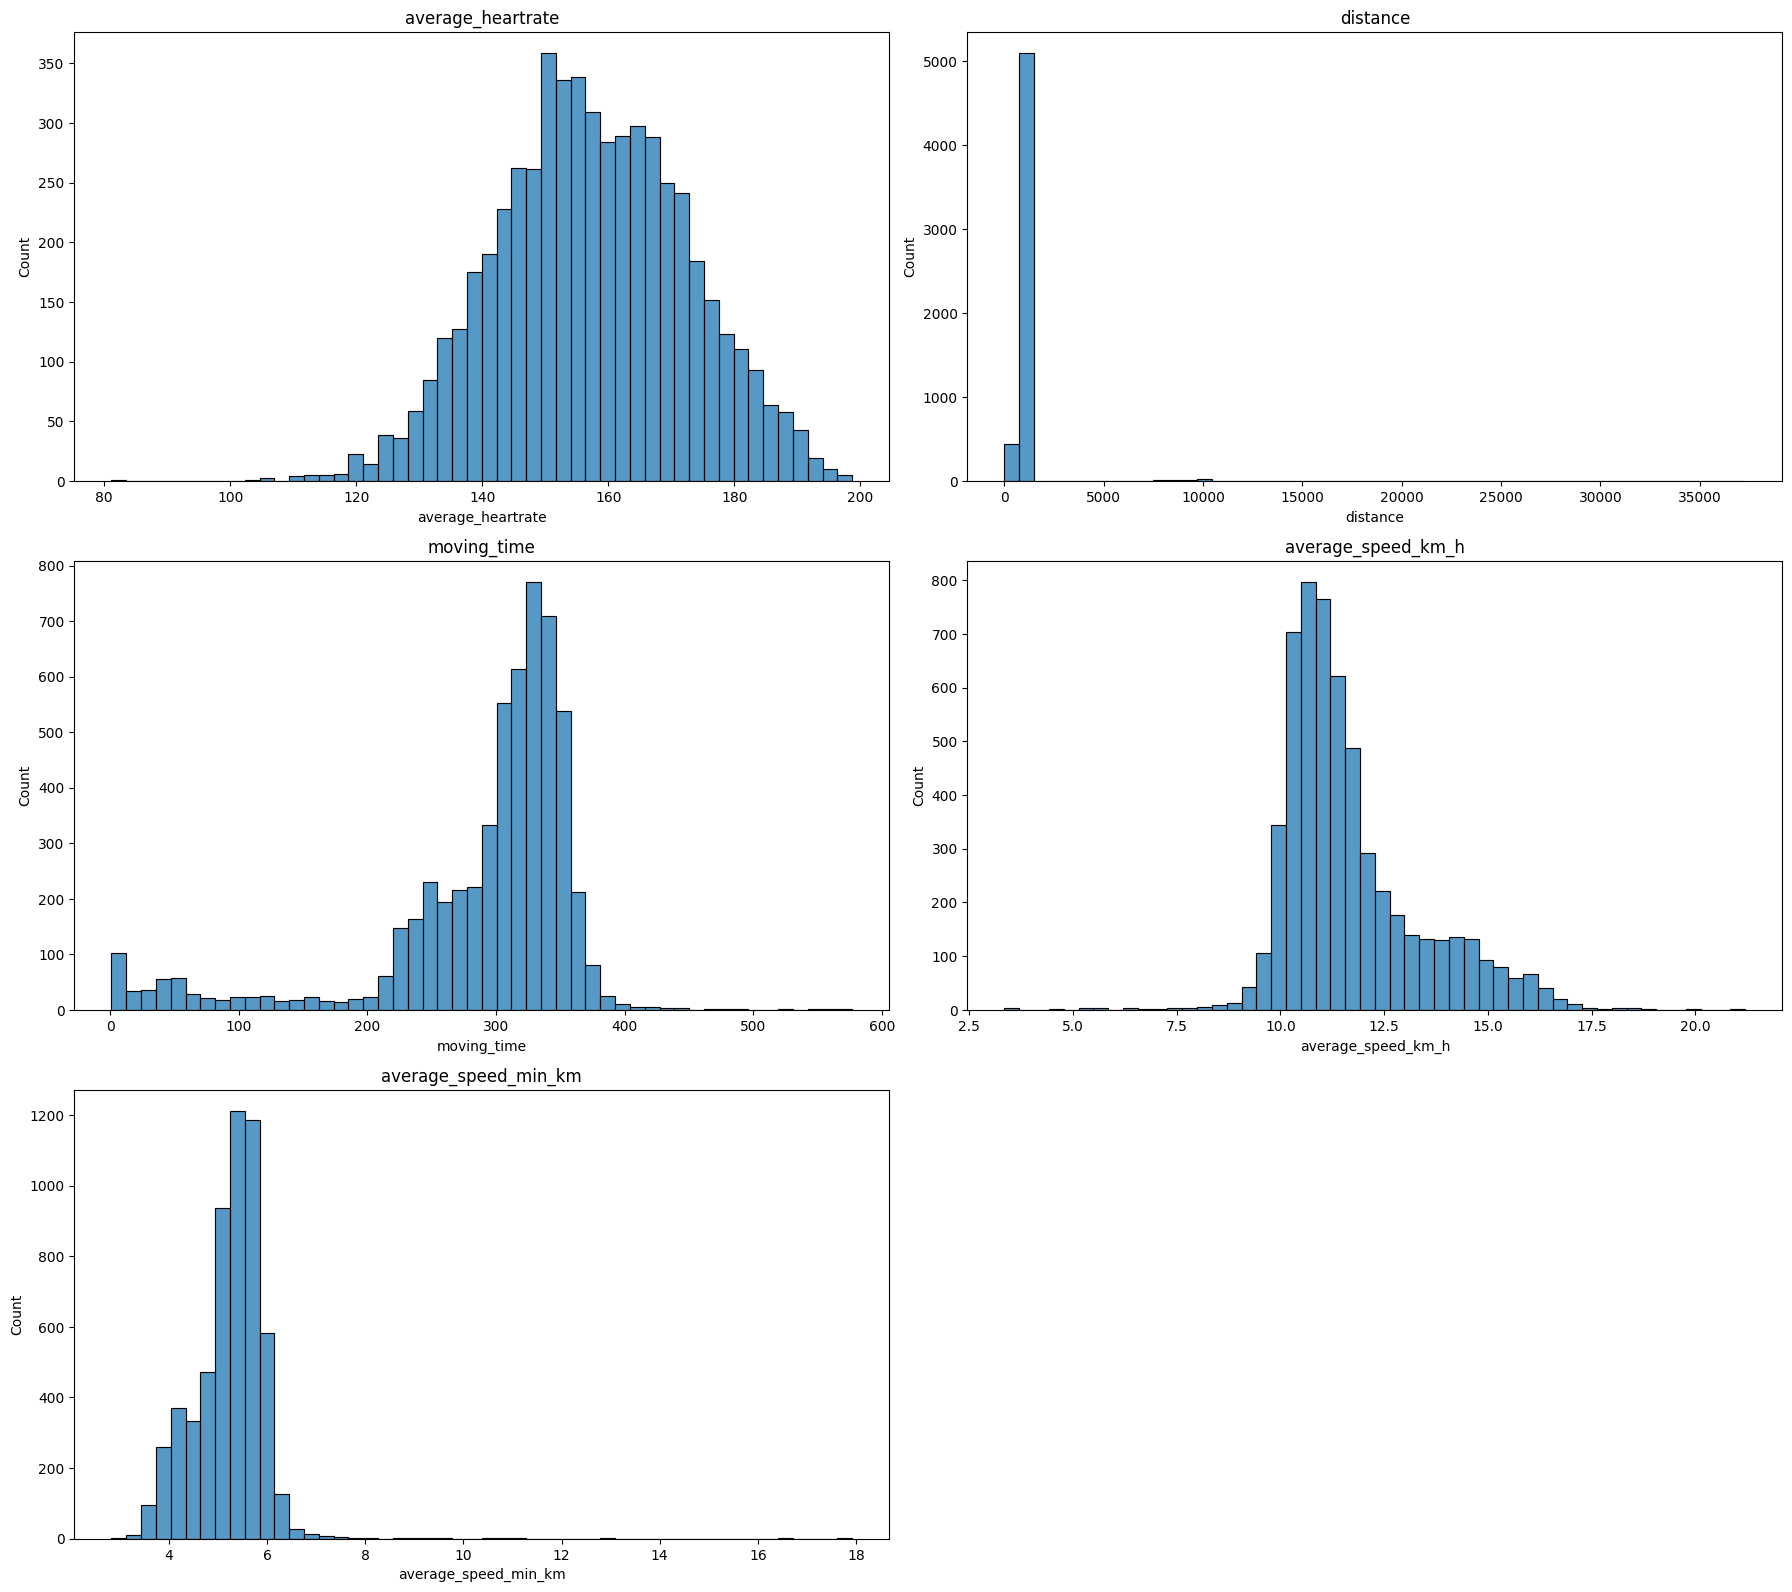

In [24]:
numerical_var = df_run[['average_heartrate', 'distance', 'moving_time', 'average_speed_km_h', 'average_speed_min_km']]

fig = plt.figure(figsize=(18, 16))

for index, col in enumerate(numerical_var.columns, 1):
    plt.subplot(3, 2, index)
    sns.histplot(df_run[col].dropna(), kde=False, bins=50)
    plt.title(col)

fig.tight_layout(pad=1.0)
plt.show()

In [ ]:
# categorical_var = df_run.select_dtypes(exclude=['number'])
# categorical_var = categorical_var.drop(columns=['start_date'])
# fig = plt.figure(figsize=(18, 16))

# for index, col in enumerate(categorical_var.columns, 1):
#     plt.subplot(6, 4, index)
#     sns.countplot(df_run[col])
#     plt.xticks(rotation = 90)
#     plt.title(col)

# fig.tight_layout(pad=1.0)
# plt.show()

### Univariate analysis (athletes_stats)

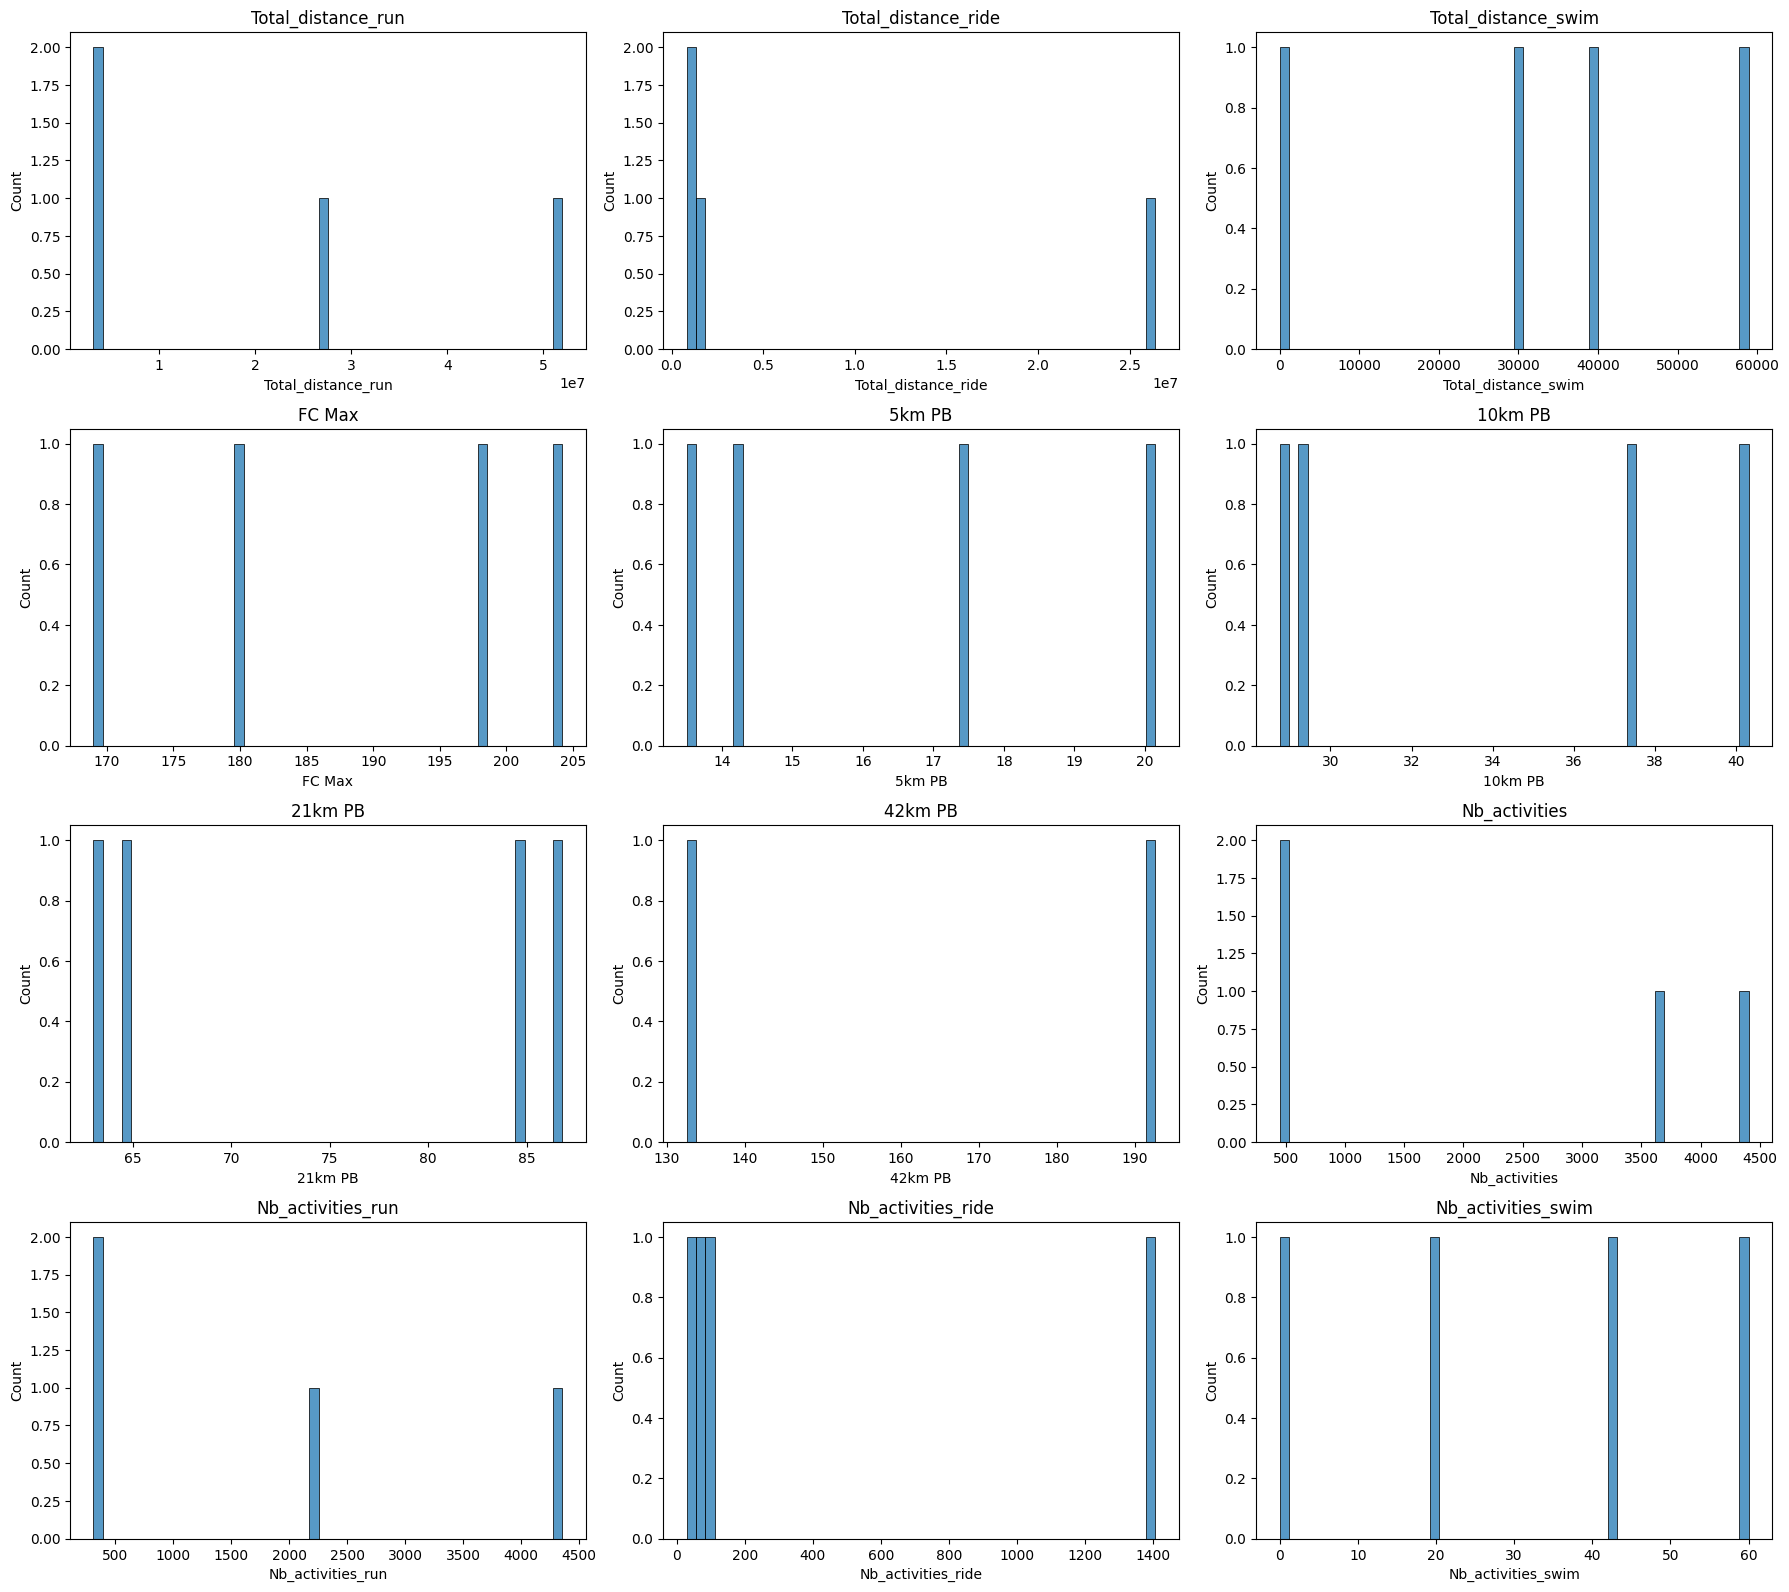

In [29]:
numerical_var2 = df_athletes_stats[['Total_distance_run', 'Total_distance_ride', 'Total_distance_swim', 'FC Max', '5km PB', '10km PB', '21km PB',
                                     '42km PB', 'Nb_activities', 'Nb_activities_run', 'Nb_activities_ride', 'Nb_activities_swim']]

fig = plt.figure(figsize=(18, 16))

for index, col in enumerate(numerical_var2.columns, 1):
    plt.subplot(4, 3, index)
    sns.histplot(df_athletes_stats[col].dropna(), kde=False, bins=50)
    plt.title(col)

fig.tight_layout(pad=1.0)
plt.show()

### Bivariate analysis

<Axes: >

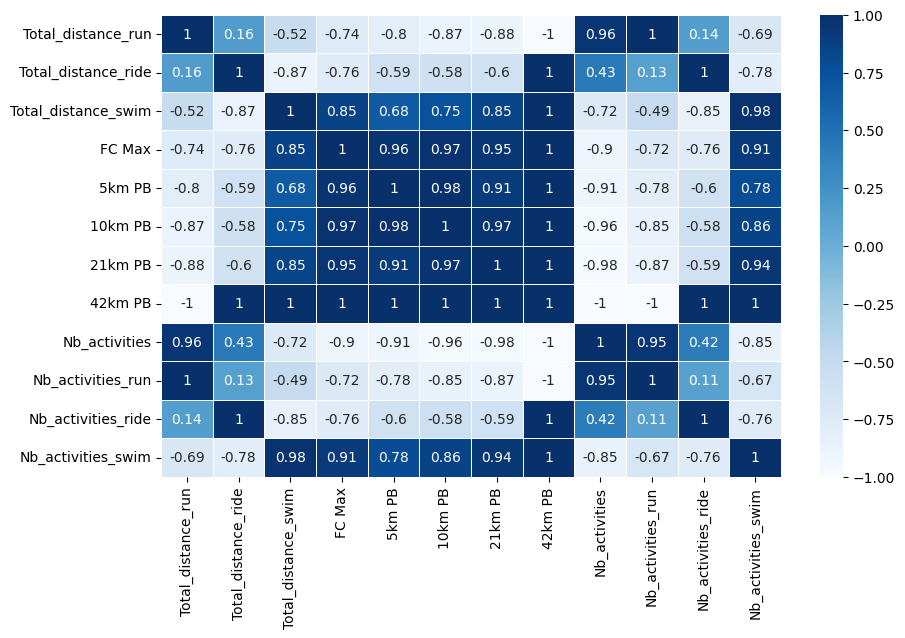

In [30]:
plt.figure(figsize=(10,6))
correlation = numerical_var2.corr()
sns.heatmap(correlation, linewidths=0.5, cmap='Blues', annot=True)